In [59]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os
import pandas as pd
import numpy as np
import edhec_risk_kit as erk

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
ind_return = erk.get_ind30_returns()
tmi_return = erk.get_total_market_index_returns()

In [60]:
#risky asset return
risky_r = ind_return['2000':][['Steel','Fin','Beer']]

In [4]:
#safe asset
safe_r = pd.DataFrame().reindex_like(risky_r)

In [5]:
safe_r[:]=0.03/12
start = 1000
floor = 0.8

In [6]:
def compound1(r):
    return ((1+r).prod() - 1)

# cppi

In [8]:
dates = risky_r.index
n_steps = len(dates)
account_value = start
floor_value = start*floor
m = 3
# something like a backtest to see what is happening
account_history = pd.DataFrame().reindex_like(risky_r)
cushion_history = pd.DataFrame().reindex_like(risky_r)
risky_w_history = pd.DataFrame().reindex_like(risky_r)

for step in range(n_steps):
    cushion = (account_value - floor_value)/ account_value
    risky_w = m * cushion
    risky_w = np.minimum(1,risky_w)
    risky_w = np.maximum(0,risky_w)
    safe_w = 1 - risky_w
    risky_alloc = account_value * risky_w
    safe_alloc = account_value * safe_w
    account_value = (risky_alloc*(1+risky_r.iloc[step])) + (safe_alloc*(1+safe_r.iloc[step]))
    # save the values and plot history
    cushion_history.iloc[step] = cushion
    account_history.iloc[step] = account_value
    risky_w_history.iloc[step] = risky_w
    

In [9]:
account_history.head()

,Steel,Fin,Beer
2000-01,984.380000,974.480000,987.320000
2000-02,1023.292876,931.167544,922.971256
2000-03,1047.555176,998.187296,924.835988
2000-04,1042.079009,973.927479,939.993701
2000-05,1007.137753,1001.460033,991.145489


<AxesSubplot:>

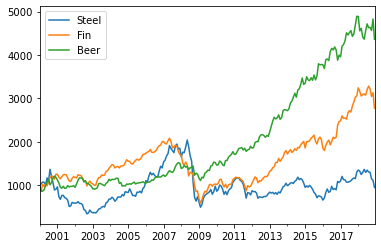

In [11]:
risky_wealth = start*(1+risky_r).cumprod()
risky_wealth.plot()

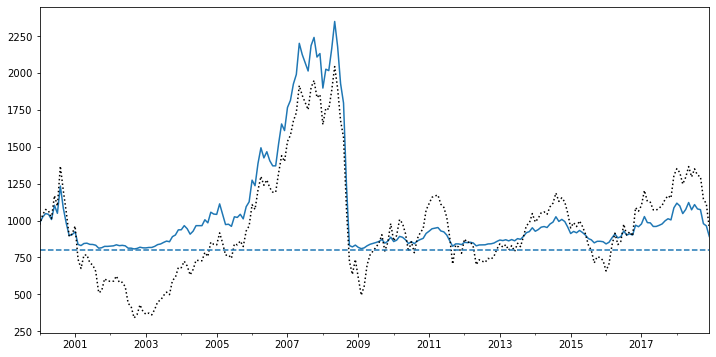

In [54]:
ax = account_history['Steel'].plot(figsize=(12,6))
risky_wealth['Steel'].plot(ax=ax , style='k:')
ax.axhline(y=floor_value, linestyle='--')

In [28]:
erk.summary_stats(risky_r)

,annualized_return,annualized_volatility,skewness,kurtosis,cornish-fisher var 5%,historic cvar 5%,sharpe ratio,max drawdown
Steel,-0.002790,0.312368,-0.326334,4.144381,0.150139,0.208117,-0.102567,-0.758017
Fin,0.055166,0.192909,-0.533218,4.995534,0.091224,0.132175,0.126718,-0.718465
Beer,0.080598,0.138925,-0.493545,4.173881,0.063015,0.091442,0.354314,-0.271368


In [29]:
btr = erk.run_cppi(risky_r)
erk.summary_stats(btr['wealth'].pct_change().dropna())

,annualized_return,annualized_volatility,skewness,kurtosis,cornish-fisher var 5%,historic cvar 5%,sharpe ratio,max drawdown
Steel,-0.005167,0.174180,-1.995143,17.110190,0.091995,0.130153,-0.196750,-0.655198
Fin,0.040894,0.131678,-0.946504,6.051414,0.065535,0.091621,0.080352,-0.549673
Beer,0.075544,0.115462,-0.669250,4.760879,0.052923,0.074908,0.383772,-0.259582


In [33]:
erk.summary_stats(btr['risky wealth'].pct_change().dropna())

,annualized_return,annualized_volatility,skewness,kurtosis,cornish-fisher var 5%,historic cvar 5%,sharpe ratio,max drawdown
Steel,-0.001320,0.312973,-0.330333,4.132666,0.150415,0.208117,-0.097801,-0.758017
Fin,0.057941,0.192986,-0.543630,5.015294,0.091172,0.132175,0.140661,-0.718465
Beer,0.082286,0.139058,-0.502368,4.181533,0.063037,0.091442,0.365788,-0.271368


<AxesSubplot:>

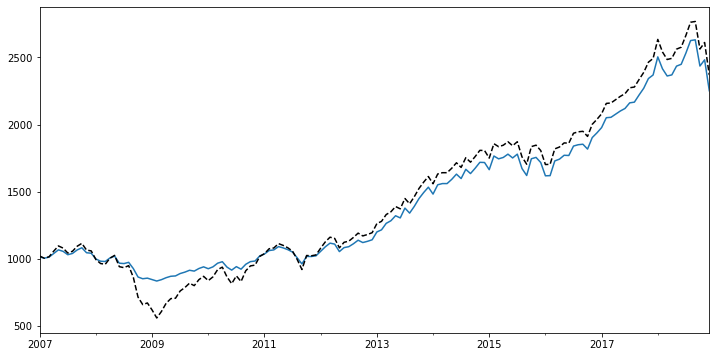

In [35]:
btr = erk.run_cppi(tmi_return['2007':])
ax = btr['wealth'].plot(figsize=(12,6),legend=False)
btr['risky wealth'].plot(ax=ax,style='k--',legend=False)

In [36]:
erk.summary_stats(btr['risky wealth'].pct_change().dropna())

,annualized_return,annualized_volatility,skewness,kurtosis,cornish-fisher var 5%,historic cvar 5%,sharpe ratio,max drawdown
R,0.073411,0.150463,-0.734939,4.523488,0.071592,0.096315,0.280618,-0.499943


In [37]:
erk.summary_stats(btr['wealth'].pct_change().dropna())

,annualized_return,annualized_volatility,skewness,kurtosis,cornish-fisher var 5%,historic cvar 5%,sharpe ratio,max drawdown
R,0.069416,0.100381,-0.588292,3.740932,0.045678,0.062953,0.382052,-0.229683


In [61]:
btr = erk.run_cppi(ind_return['2007':][['Steel','Fin','Beer']],drawdown=0.25)

<AxesSubplot:>

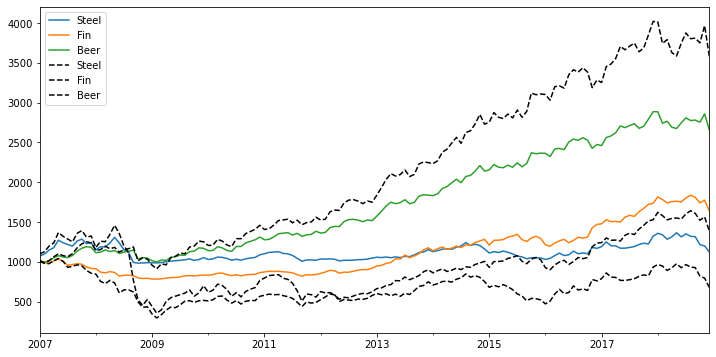

In [62]:
ax = btr['wealth'].plot(figsize=(12,6))
btr['risky wealth'].plot(ax=ax,style='k--')

In [51]:
erk.summary_stats(btr['risky wealth'].pct_change().dropna())

,annualized_return,annualized_volatility,skewness,kurtosis,cornish-fisher var 5%,historic cvar 5%,sharpe ratio,max drawdown
Steel,-0.039660,0.306407,-0.459951,4.782828,0.152288,0.203837,-0.221642,-0.758017
Fin,0.027364,0.212204,-0.695200,4.621401,0.105744,0.149862,-0.012370,-0.718465
Beer,0.111554,0.127971,-0.670797,4.650878,0.056497,0.077388,0.620132,-0.271368


In [63]:
erk.summary_stats(btr['wealth'].pct_change().dropna())

,annualized_return,annualized_volatility,skewness,kurtosis,cornish-fisher var 5%,historic cvar 5%,sharpe ratio,max drawdown
Steel,0.003784,0.097073,-0.441089,5.220481,0.047371,0.066991,-0.262958,-0.248059
Fin,0.041975,0.085028,-0.355163,4.153860,0.038342,0.054111,0.136964,-0.243626
Beer,0.084375,0.086263,-0.744111,4.571533,0.037937,0.051189,0.613413,-0.161186
